# Calculus for Machine Learning & Deep Learning

Calculus is the engine behind every learning algorithm. When a neural network **trains**, it is doing calculus — computing derivatives to figure out which direction to move its weights to reduce error.

| Section | Topic | Used In |
|---|---|---|
| 1 | Derivatives & Gradients | Every optimizer |
| 2 | Chain Rule | Backpropagation |
| 3 | Partial Derivatives | Loss w.r.t. weights |
| 4 | Gradient Descent | Training loop |
| 5 | Activation Functions & their Derivatives | Forward + backward pass |
| 6 | Backpropagation from scratch | Neural network training |
| 7 | Jacobians & Hessians | Advanced optimizers, curvature |
| 8 | Calculus in Transformers | Attention gradient flow |
| 9 | Calculus in Generative AI | VAE loss, diffusion noise schedule |

In [11]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

def numerical_derivative(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)

---
## 1. Derivatives & Gradients

A **derivative** measures how much a function output changes when you nudge its input.

$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

In ML, the function is always the **loss**, and the input is always a **weight**:

$$\frac{\partial L}{\partial w} = \text{how much does loss change if I nudge weight } w?$$

- **Positive derivative** → loss goes up if we increase `w` → move `w` down  
- **Negative derivative** → loss goes down if we increase `w` → move `w` up  
- **Zero derivative** → we are at a minimum (or saddle point)

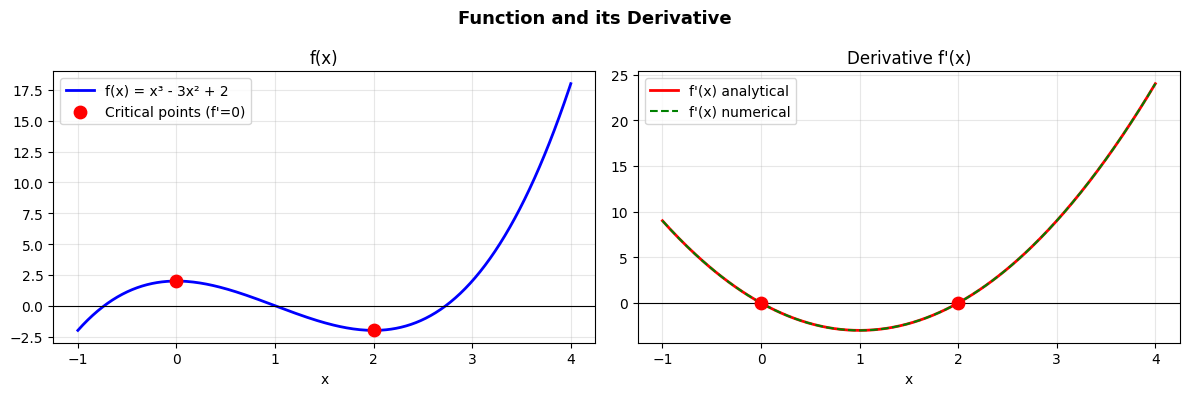

At x=1.5:  analytical=-2.250000  numerical=-2.250000


In [12]:
def f(x):
    return x**3 - 3*x**2 + 2

def f_prime(x):
    return 3*x**2 - 6*x      # analytical

x = np.linspace(-1, 4, 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x, f(x), 'b-', lw=2, label='f(x) = x³ - 3x² + 2')
axes[0].scatter([0, 2], [f(0), f(2)], color='red', zorder=5, s=80, label="Critical points (f'=0)")
axes[0].axhline(0, color='k', lw=0.8)
axes[0].set_title('f(x)')
axes[0].set_xlabel('x')
axes[0].legend()

axes[1].plot(x, f_prime(x), 'r-', lw=2, label="f'(x) analytical")
axes[1].plot(x, [numerical_derivative(f, xi) for xi in x], 'g--', lw=1.5, label="f'(x) numerical")
axes[1].axhline(0, color='k', lw=0.8)
axes[1].scatter([0, 2], [0, 0], color='red', zorder=5, s=80)
axes[1].set_title("Derivative f'(x)")
axes[1].set_xlabel('x')
axes[1].legend()

plt.suptitle('Function and its Derivative', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

x0 = 1.5
print(f'At x={x0}:  analytical={f_prime(x0):.6f}  numerical={numerical_derivative(f, x0):.6f}')

---
## 2. The Chain Rule — Heart of Backpropagation

When functions are **nested**, multiply their derivatives:

$$\frac{d}{dx}[f(g(x))] = f'(g(x)) \cdot g'(x)$$

A neural network is a composition of many nested functions:

```
L = loss( activation( W · x + b ) )

dL/dW = dL/da · da/dz · dz/dW
         ↑        ↑        ↑
      loss     activ    linear
```

Backpropagation **is** the chain rule — applied layer by layer from output to input.

In [13]:
# Chain rule walkthrough: single neuron
# Forward: z = w*x + b  →  a = tanh(z)  →  L = (a - target)²

x0, w, b, target = 2.0, 0.5, 0.1, 1.0

# Forward
z = w * x0 + b
a = np.tanh(z)
L = (a - target)**2

print('=== Forward Pass ===')
print(f'  z = w*x + b = {w}*{x0} + {b} = {z}')
print(f'  a = tanh(z) = {a:.4f}')
print(f'  L = (a - 1)\u00b2 = {L:.6f}')

# Backward (chain rule)
dL_da = 2 * (a - target)          # dL/da
da_dz = 1 - np.tanh(z)**2         # d tanh/dz
dz_dw = x0                        # dz/dw
dz_db = 1.0                       # dz/db

dL_dw = dL_da * da_dz * dz_dw
dL_db = dL_da * da_dz * dz_db

print('\n=== Backward Pass (Chain Rule) ===')
print(f'  dL/da = 2(a-1)     = {dL_da:.4f}')
print(f'  da/dz = 1-tanh\u00b2(z) = {da_dz:.4f}')
print(f'  dz/dw = x          = {dz_dw}')
print(f'  dL/dw = {dL_da:.4f} * {da_dz:.4f} * {dz_dw} = {dL_dw:.6f}')
print(f'  dL/db = {dL_da:.4f} * {da_dz:.4f} * {dz_db} = {dL_db:.6f}')

# Verify with numerical gradient
def loss_fn(w_):
    return (np.tanh(w_ * x0 + b) - target)**2

print(f'\n  Numerical dL/dw = {numerical_derivative(loss_fn, w):.6f}  (matches above)')

=== Forward Pass ===
  z = w*x + b = 0.5*2.0 + 0.1 = 1.1
  a = tanh(z) = 0.8005
  L = (a - 1)² = 0.039801

=== Backward Pass (Chain Rule) ===
  dL/da = 2(a-1)     = -0.3990
  da/dz = 1-tanh²(z) = 0.3592
  dz/dw = x          = 2.0
  dL/dw = -0.3990 * 0.3592 * 2.0 = -0.286644
  dL/db = -0.3990 * 0.3592 * 1.0 = -0.143322

  Numerical dL/dw = -0.286644  (matches above)


---
## 3. Partial Derivatives & the Gradient

When a loss depends on **many weights**, we differentiate with respect to each one:

$$\nabla_w L = \left[\frac{\partial L}{\partial w_1},\ \frac{\partial L}{\partial w_2},\ \ldots,\ \frac{\partial L}{\partial w_n}\right]$$

> The gradient points toward **steepest ascent**.  
> To minimize loss → step in the **negative** gradient direction.

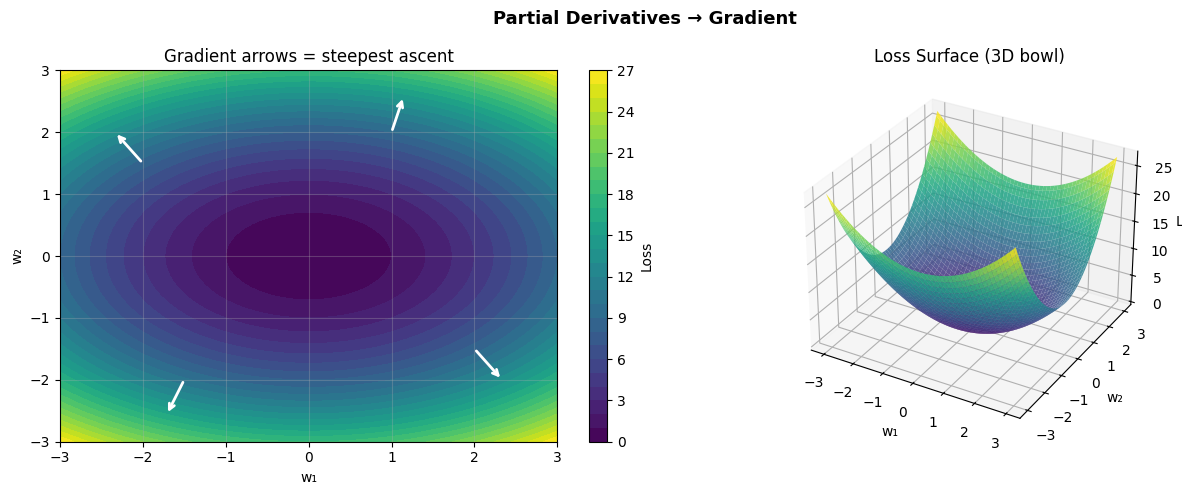

In [14]:
# L(w1, w2) = w1² + 2*w2²  — gradient = [2*w1, 4*w2]
def loss_surface(w1, w2):
    return w1**2 + 2*w2**2

def gradient(w1, w2):
    return np.array([2*w1, 4*w2])

w1 = np.linspace(-3, 3, 100)
w2 = np.linspace(-3, 3, 100)
W1, W2 = np.meshgrid(w1, w2)
L = loss_surface(W1, W2)

fig = plt.figure(figsize=(13, 5))

ax1 = fig.add_subplot(121)
cs = ax1.contourf(W1, W2, L, levels=30, cmap='viridis')
plt.colorbar(cs, ax=ax1, label='Loss')
for p in [(-2, 1.5), (2, -1.5), (-1.5, -2), (1, 2)]:
    g = gradient(*p)
    g_n = g / (np.linalg.norm(g) + 1e-8) * 0.6
    ax1.annotate('', xy=(p[0]+g_n[0], p[1]+g_n[1]), xytext=p,
                arrowprops=dict(arrowstyle='->', color='white', lw=2))
ax1.set_title('Gradient arrows = steepest ascent')
ax1.set_xlabel('w₁')
ax1.set_ylabel('w₂')

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(W1, W2, L, cmap='viridis', alpha=0.85)
ax2.set_title('Loss Surface (3D bowl)')
ax2.set_xlabel('w₁')
ax2.set_ylabel('w₂')
ax2.set_zlabel('Loss')

plt.suptitle('Partial Derivatives → Gradient', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Gradient Descent — The Training Loop

$$w \leftarrow w - \eta \cdot \nabla_w L$$

| Optimizer | Key idea | Used in |
|---|---|---|
| **SGD** | Raw gradient step | CNNs with momentum |
| **Adam** | Adaptive lr + momentum | Transformers, most DL |
| **AdamW** | Adam + weight decay | GPT, BERT fine-tuning |

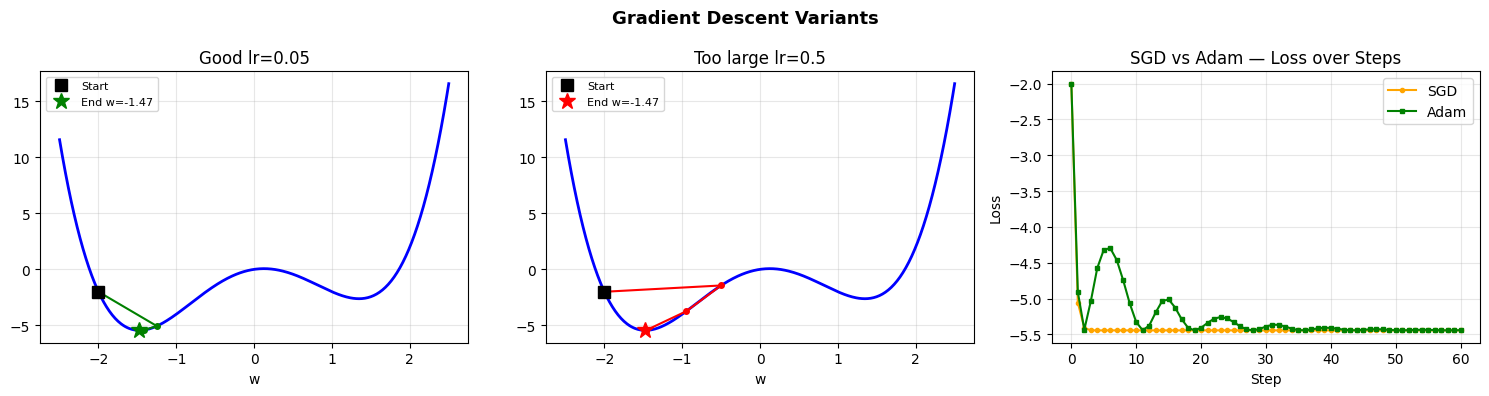

In [15]:
# Non-convex loss: L(w) = w⁴ - 4w² + w  (two local minima)
def L_fn(w):
    return w**4 - 4*w**2 + w

def dL_fn(w):
    return 4*w**3 - 8*w + 1

def sgd(start, lr, steps):
    w, path = start, [start]
    for _ in range(steps):
        w -= lr * dL_fn(w)
        path.append(w)
    return np.array(path)

def adam(start, lr=0.3, steps=60, b1=0.9, b2=0.999, eps=1e-8):
    w, m, v = start, 0.0, 0.0
    path = [w]
    for t in range(1, steps+1):
        g = dL_fn(w)
        m = b1*m + (1-b1)*g
        v = b2*v + (1-b2)*g**2
        w -= lr * (m/(1-b1**t)) / (np.sqrt(v/(1-b2**t)) + eps)
        path.append(w)
    return np.array(path)

w_range = np.linspace(-2.5, 2.5, 400)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Learning rate comparison
for ax, (title, lr, color) in zip(axes[:2], [
    ('Good lr=0.05', 0.05, 'green'),
    ('Too large lr=0.5', 0.1, 'red')]):
    path = sgd(-2.0, lr, 50)
    ax.plot(w_range, L_fn(w_range), 'b-', lw=2)
    ax.plot(path, L_fn(path), 'o-', color=color, ms=4, lw=1.5)
    ax.plot(path[0], L_fn(path[0]), 's', color='black', ms=8, label='Start')
    ax.plot(path[-1], L_fn(path[-1]), '*', color=color, ms=12, label=f'End w={path[-1]:.2f}')
    ax.set_title(title)
    ax.set_xlabel('w')
    ax.legend(fontsize=8)

# SGD vs Adam convergence
sgd_path  = sgd(-2.0, 0.05, 60)
adam_path = adam(-2.0, 0.3, 60)
axes[2].plot(L_fn(sgd_path),  'o-', color='orange', ms=3, label='SGD')
axes[2].plot(L_fn(adam_path), 's-', color='green',  ms=3, label='Adam')
axes[2].set_title('SGD vs Adam — Loss over Steps')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('Loss')
axes[2].legend()

plt.suptitle('Gradient Descent Variants', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Activation Functions & Their Derivatives

Activations add **non-linearity** — without them, deep networks collapse into one linear layer.  
Their **derivatives** are what backprop multiplies through during the backward pass.

| Activation | Derivative | Key issue |
|---|---|---|
| Sigmoid | `σ(x)(1-σ(x))` | Saturates → vanishing gradient |
| Tanh | `1 - tanh²(x)` | Saturates → vanishing gradient |
| ReLU | `0 if x<0, 1 if x>0` | Dying ReLU (dead neurons) |
| GELU | smooth approx | Used in GPT, BERT, ViT |

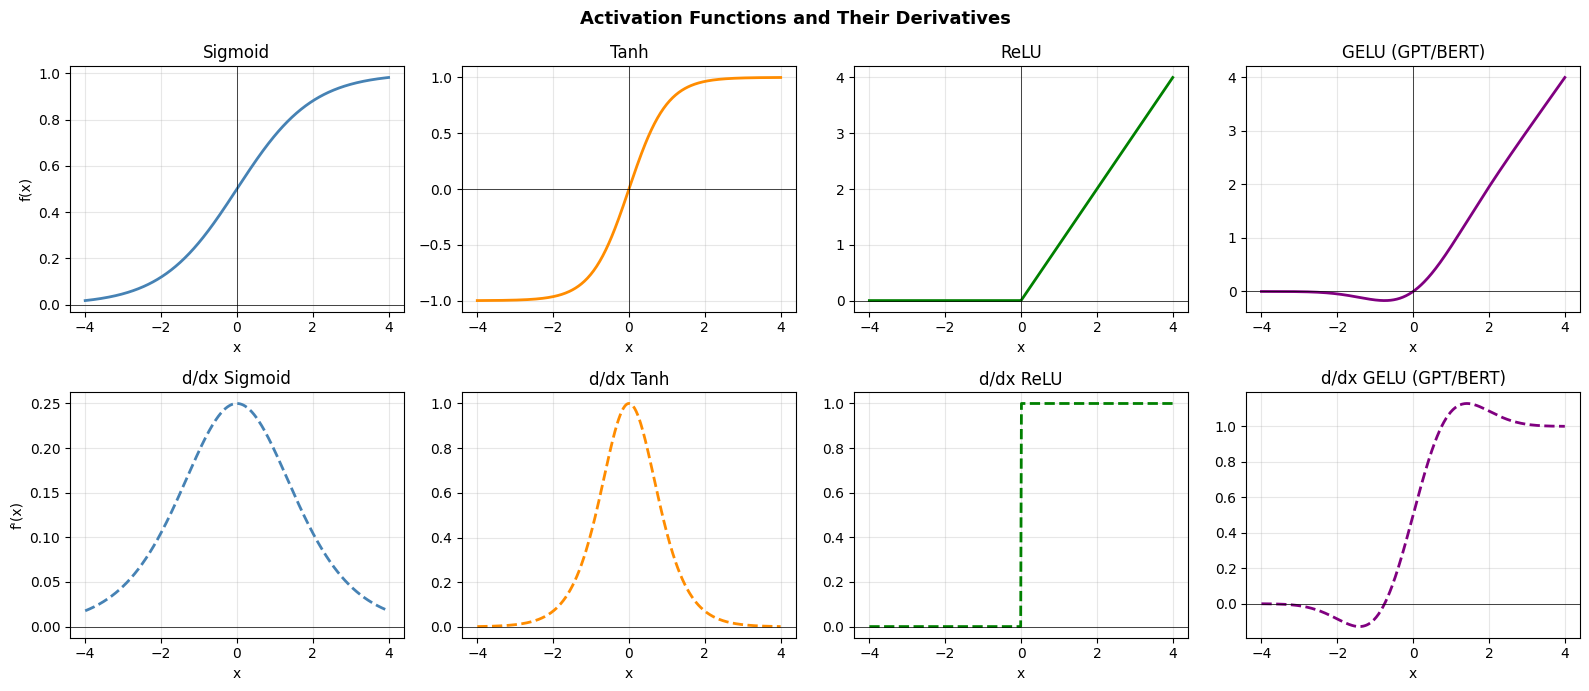

=== Vanishing Gradient: Sigmoid derivative at large |x| ===
  sigmoid'(-5) = 0.006648  <-- nearly ZERO
  sigmoid'(-3) = 0.045177  <-- nearly ZERO
  sigmoid'(+0) = 0.250000  
  sigmoid'(+3) = 0.045177  <-- nearly ZERO
  sigmoid'(+5) = 0.006648  <-- nearly ZERO


In [16]:
x = np.linspace(-4, 4, 400)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))
def d_sigmoid(x):
    return sigmoid(x) * (1 - sigmoid(x))
def d_tanh(x):
    return 1 - np.tanh(x)**2
def relu(x):
    return np.maximum(0, x)
def d_relu(x):
    return (x > 0).astype(float)
def gelu(x):
    return x * 0.5 * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715*x**3)))

configs = [
    ('Sigmoid', sigmoid, d_sigmoid, 'steelblue'),
    ('Tanh', np.tanh, d_tanh, 'darkorange'),
    ('ReLU', relu, d_relu, 'green'),
    ('GELU (GPT/BERT)', gelu, None, 'purple'),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, (name, f, df, color) in enumerate(configs):
    axes[0, i].plot(x, f(x), color=color, lw=2)
    axes[0, i].set_title(name)
    axes[0, i].set_xlabel('x')
    axes[0, i].axhline(0, color='k', lw=0.5)
    axes[0, i].axvline(0, color='k', lw=0.5)

    grad = df(x) if df is not None else np.array([numerical_derivative(gelu, xi) for xi in x])
    axes[1, i].plot(x, grad, color=color, lw=2, linestyle='--')
    axes[1, i].set_title(f"d/dx {name}")
    axes[1, i].set_xlabel('x')
    axes[1, i].axhline(0, color='k', lw=0.5)

axes[0, 0].set_ylabel('f(x)')
axes[1, 0].set_ylabel("f'(x)")
plt.suptitle('Activation Functions and Their Derivatives', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== Vanishing Gradient: Sigmoid derivative at large |x| ===')
for xv in [-5, -3, 0, 3, 5]:
    d = d_sigmoid(xv)
    print(f'  sigmoid\'({xv:+d}) = {d:.6f}  {"<-- nearly ZERO" if abs(d) < 0.05 else ""}')

---
## 6. Backpropagation from Scratch

We build a **2-layer network** and train it on XOR — a non-linearly separable problem.  
Every gradient is computed manually using the chain rule.

```
Forward:   X → [W1,b1] → z1 → ReLU → a1 → [W2,b2] → z2 → sigmoid → ŷ → Loss
Backward:  dL/dW1 ← dL/da1 ← dL/dz2 ← dL/dŷ
```

Final loss: 0.003670

Predictions vs True (XOR):
  [0 0] → P=0.0111  pred=0  true=0
  [0 1] → P=0.9983  pred=1  true=1
  [1 0] → P=0.9991  pred=1  true=1
  [1 1] → P=0.0010  pred=0  true=0


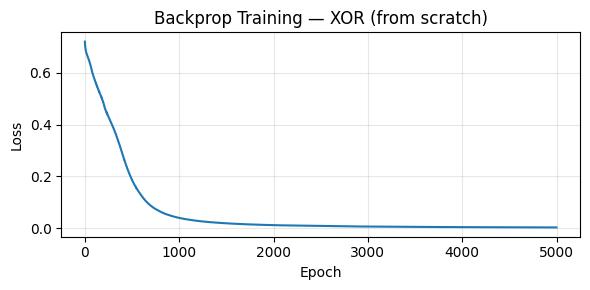

In [17]:
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y = np.array([[0],[1],[1],[0]], dtype=float)  # XOR

np.random.seed(0)
W1, b1 = np.random.randn(2, 4) * 0.5, np.zeros((1, 4))
W2, b2 = np.random.randn(4, 1) * 0.5, np.zeros((1, 1))
lr = 0.1

def relu(z):
    return np.maximum(0, z)
def d_relu(z):
    return (z > 0).astype(float)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

losses = []
for epoch in range(5000):
    # Forward
    z1    = X @ W1 + b1
    a1    = relu(z1)
    z2    = a1 @ W2 + b2
    y_hat = sigmoid(z2)
    loss  = -np.mean(y * np.log(y_hat+1e-9) + (1-y) * np.log(1-y_hat+1e-9))
    losses.append(loss)

    # Backward
    dL_dz2 = (-(y/(y_hat+1e-9) - (1-y)/(1-y_hat+1e-9)) * y_hat*(1-y_hat)) / len(y)
    dL_dW2 = a1.T @ dL_dz2
    dL_db2 = dL_dz2.sum(axis=0, keepdims=True)
    dL_dz1 = (dL_dz2 @ W2.T) * d_relu(z1)
    dL_dW1 = X.T @ dL_dz1
    dL_db1 = dL_dz1.sum(axis=0, keepdims=True)

    W2 -= lr * dL_dW2
    b2 -= lr * dL_db2
    W1 -= lr * dL_dW1
    b1 -= lr * dL_db1

print(f'Final loss: {losses[-1]:.6f}')
print()
print('Predictions vs True (XOR):')
for xi, yi in zip(X, y):
    pred = sigmoid(relu(xi @ W1 + b1) @ W2 + b2)[0, 0]
    print(f'  {xi.astype(int)} → P={pred:.4f}  pred={int(pred>0.5)}  true={int(yi[0])}')

plt.figure(figsize=(6, 3))
plt.plot(losses, lw=1.5)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Backprop Training — XOR (from scratch)')
plt.tight_layout()
plt.show()

---
## 7. Jacobians & Hessians

### Jacobian — vector-to-vector derivative
When a function maps **vector → vector**, the Jacobian is a matrix of all partials:
$$J_{ij} = \frac{\partial f_i}{\partial x_j}$$
Used in: **Softmax backward**, batch normalization gradient.

### Hessian — second-order curvature
$$H_{ij} = \frac{\partial^2 L}{\partial w_i \partial w_j}$$
- All eigenvalues **positive** → true minimum  
- Mixed signs → **saddle point** (very common in deep networks!)

In [18]:
def softmax(x):
    return np.exp(x - x.max()) / np.exp(x - x.max()).sum()

def softmax_jacobian(x):
    s = softmax(x)
    return np.diag(s) - np.outer(s, s)

logits = np.array([2.0, 1.0, 0.5])
print('=== Softmax Jacobian (used in cross-entropy backprop) ===')
print('Logits  :', logits)
print('Softmax :', softmax(logits).round(4))
print('Jacobian:')
print(softmax_jacobian(logits).round(4))

print()
print('=== Hessian of L(w1,w2) = w1² + 2w2² ===')
H = np.array([[2, 0], [0, 4]])
eigvals = np.linalg.eigvals(H)
print('H =', H)
print('Eigenvalues:', eigvals, '→ All positive → TRUE MINIMUM')

print()
print('=== Hessian of saddle: L = w1² - w2² ===')
H_saddle = np.array([[2, 0], [0, -2]])
print('Eigenvalues:', np.linalg.eigvals(H_saddle), '→ Mixed signs → SADDLE POINT')
print('Saddle points are everywhere in deep networks — Adam handles them better than SGD.')

=== Softmax Jacobian (used in cross-entropy backprop) ===
Logits  : [2.  1.  0.5]
Softmax : [0.6285 0.2312 0.1402]
Jacobian:
[[ 0.2335 -0.1453 -0.0881]
 [-0.1453  0.1778 -0.0324]
 [-0.0881 -0.0324  0.1206]]

=== Hessian of L(w1,w2) = w1² + 2w2² ===
H = [[2 0]
 [0 4]]
Eigenvalues: [2. 4.] → All positive → TRUE MINIMUM

=== Hessian of saddle: L = w1² - w2² ===
Eigenvalues: [ 2. -2.] → Mixed signs → SADDLE POINT
Saddle points are everywhere in deep networks — Adam handles them better than SGD.


---
## 8. Calculus in Transformers — Attention Gradient Flow

$$\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Calculus shows up in **two critical places**:

1. **Softmax Jacobian** — flows gradients from output back to `QKᵀ` scores  
2. **The `√d_k` scaling** — prevents vanishing gradients when `d_k` is large

### Why √d_k matters:
With large `d_k`, dot products grow large → softmax saturates → derivative ≈ 0 → **vanishing gradient**.  
Dividing by `√d_k` keeps variance of scores at ~1, keeping gradients healthy.

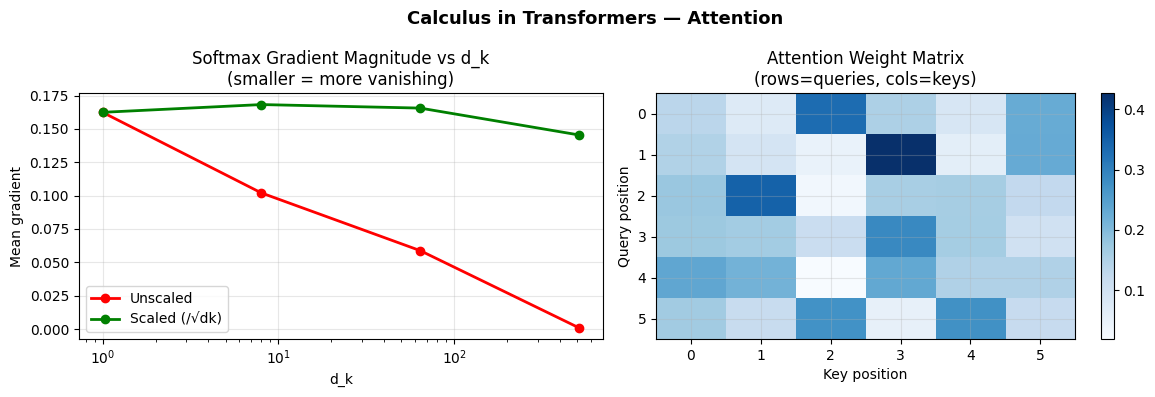

Without /√dk: gradient → 0 as dk grows (vanishing gradient in attention).
With    /√dk: gradient stays healthy regardless of embedding size.


In [19]:
d_k_values = [1, 8, 64, 512]
grad_unscaled, grad_scaled = [], []

np.random.seed(42)
for dk in d_k_values:
    Q = np.random.randn(4, dk)
    K = np.random.randn(4, dk)
    scores_raw    = Q @ K.T
    scores_scaled = scores_raw / np.sqrt(dk)
    s_raw    = np.array([softmax(r) for r in scores_raw])
    s_scaled = np.array([softmax(r) for r in scores_scaled])
    grad_unscaled.append(np.mean(s_raw * (1 - s_raw)))
    grad_scaled.append(np.mean(s_scaled * (1 - s_scaled)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(d_k_values, grad_unscaled, 'ro-', lw=2, label='Unscaled')
axes[0].plot(d_k_values, grad_scaled,   'go-', lw=2, label='Scaled (/√dk)')
axes[0].set_xscale('log')
axes[0].set_title('Softmax Gradient Magnitude vs d_k\n(smaller = more vanishing)')
axes[0].set_xlabel('d_k')
axes[0].set_ylabel('Mean gradient')
axes[0].legend()

# Attention weight matrix
np.random.seed(1)
Q2 = np.random.randn(6, 8)
K2 = np.random.randn(6, 8)
V2 = np.random.randn(6, 8)
scores = Q2 @ K2.T / np.sqrt(8)
attn_weights = np.array([softmax(r) for r in scores])

im = axes[1].imshow(attn_weights, cmap='Blues', aspect='auto')
plt.colorbar(im, ax=axes[1])
axes[1].set_title('Attention Weight Matrix\n(rows=queries, cols=keys)')
axes[1].set_xlabel('Key position')
axes[1].set_ylabel('Query position')

plt.suptitle('Calculus in Transformers — Attention', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Without /√dk: gradient → 0 as dk grows (vanishing gradient in attention).')
print('With    /√dk: gradient stays healthy regardless of embedding size.')

---
## 9. Calculus in Generative AI

### 9a. VAE — Reparameterization Trick
The VAE loss:
$$\mathcal{L}_{VAE} = \underbrace{\mathbb{E}[\log p(x|z)]}_{\text{Reconstruction}} - \underbrace{D_{KL}(q(z|x)\|p(z))}_{\text{KL divergence}}$$

The problem: sampling `z ~ N(μ, σ²)` is **not differentiable** — gradients can't flow back through a random sample.  
The fix — reparameterize:
```
z = μ + σ · ε,    ε ~ N(0,1)
```
Now gradients flow through `μ` and `σ` — the random part `ε` is just a constant.

### 9b. Diffusion — Noise Schedule
Diffusion models add noise forward: `x_t = √ᾱ_t · x₀ + √(1-ᾱ_t) · ε`  
The model learns to **predict the noise `ε`** and is trained with:
$$\mathcal{L} = \mathbb{E}\left[\|\epsilon - \epsilon_\theta(x_t, t)\|^2\right]$$

=== VAE KL Loss ===
  μ=+0.0, logσ²=+0.0  →  KL=-0.0000  ∂KL/∂μ=+0.000  ∂KL/∂logσ²=-0.000
  μ=+1.0, logσ²=+0.0  →  KL=0.5000  ∂KL/∂μ=+1.000  ∂KL/∂logσ²=-0.000
  μ=+0.0, logσ²=+1.0  →  KL=0.3591  ∂KL/∂μ=+0.000  ∂KL/∂logσ²=+0.859
  μ=+2.0, logσ²=+1.0  →  KL=2.3591  ∂KL/∂μ=+2.000  ∂KL/∂logσ²=+0.859

=== Reparameterization Trick ===
  mu      = [ 0.5 -0.3]
  sigma   = [0.9048 1.0513]
  epsilon = [0.5295 0.1377]   <- random constant, no gradient
  z       = [ 0.9791 -0.1552]
  dL/dmu and dL/dsigma flow normally. dL/deps does not exist.


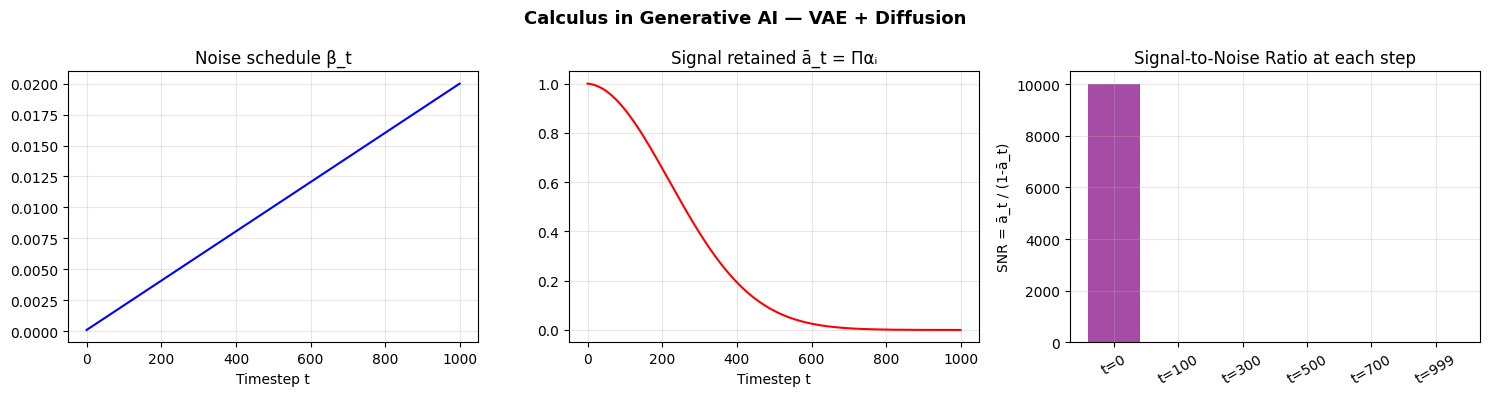

In [20]:
# ── VAE: KL divergence + gradient ───────────────────────────────────────────
def kl_loss(mu, log_var):
    """KL( N(mu,var) || N(0,1) ) — closed form"""
    return -0.5 * np.sum(1 + log_var - mu**2 - np.exp(log_var))

print('=== VAE KL Loss ===')
for mu_v, lv_v in [(0.0, 0.0), (1.0, 0.0), (0.0, 1.0), (2.0, 1.0)]:
    kl = kl_loss(np.array([mu_v]), np.array([lv_v]))
    gmu = mu_v                             # dKL/dmu = mu
    glv = -0.5 * (1 - np.exp(lv_v))       # dKL/d(logvar)
    print(f'  μ={mu_v:+.1f}, logσ²={lv_v:+.1f}  →  KL={kl:.4f}  ∂KL/∂μ={gmu:+.3f}  ∂KL/∂logσ²={glv:+.3f}')

print()
print('=== Reparameterization Trick ===')
mu_enc  = np.array([0.5, -0.3])
lv_enc  = np.array([-0.2, 0.1])
eps     = np.random.randn(2)
z       = mu_enc + np.exp(0.5 * lv_enc) * eps
print(f'  mu      = {mu_enc}')
print(f'  sigma   = {np.exp(0.5*lv_enc).round(4)}')
print(f'  epsilon = {eps.round(4)}   <- random constant, no gradient')
print(f'  z       = {z.round(4)}')
print('  dL/dmu and dL/dsigma flow normally. dL/deps does not exist.')

# ── Diffusion noise schedule ─────────────────────────────────────────────────
T = 1000
betas      = np.linspace(1e-4, 0.02, T)
alpha_bars = np.cumprod(1 - betas)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(betas, 'b-', lw=1.5)
axes[0].set_title('Noise schedule β_t')
axes[0].set_xlabel('Timestep t')

axes[1].plot(alpha_bars, 'r-', lw=1.5)
axes[1].set_title('Signal retained ā_t = Παᵢ')
axes[1].set_xlabel('Timestep t')

x0 = 1.0
timesteps = [0, 100, 300, 500, 700, 999]
snr = [alpha_bars[t] / (1 - alpha_bars[t]) for t in timesteps]
axes[2].bar(range(len(timesteps)), snr, color='purple', alpha=0.7)
axes[2].set_xticks(range(len(timesteps)))
axes[2].set_xticklabels([f't={t}' for t in timesteps], rotation=30)
axes[2].set_title('Signal-to-Noise Ratio at each step')
axes[2].set_ylabel('SNR = ā_t / (1-ā_t)')

plt.suptitle('Calculus in Generative AI — VAE + Diffusion', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Summary — Calculus Across the Whole Stack

```
Classic ML
  └── Derivative of MSE / cross-entropy  →  gradient descent

Deep Learning
  └── Chain rule layer by layer           →  backpropagation
      └── Activation derivatives            →  ReLU/GELU preferred over sigmoid
          └── Jacobian of softmax           →  classification head gradient
              └── Hessian curvature         →  saddle points everywhere

Transformers
  └── Softmax Jacobian in attention        →  gradient flows Q, K, V
      └── √dk scaling                      →  prevents vanishing gradient in attention

Generative AI
  └── KL divergence gradient (VAE)        →  encoder learns latent space
      └── Reparameterization trick          →  makes sampling differentiable
          └── MSE on noise (Diffusion)      →  model learns to denoise
```

| Concept | Formula | Where |
|---|---|---|
| Derivative | `f'(x) = lim(f(x+h)-f(x))/h` | Every optimizer |
| Chain rule | `dL/dx = dL/da · da/dz · dz/dx` | Backprop |
| Gradient | `∇L = [∂L/∂w₁ ... ∂L/∂wₙ]` | Gradient descent |
| Update rule | `w ← w - η∇L` | SGD, Adam |
| Jacobian | `J[i,j] = ∂fᵢ/∂xⱼ` | Softmax backward |
| Hessian | `H[i,j] = ∂²L/∂wᵢ∂wⱼ` | Curvature, saddle detection |
| Reparam trick | `z = μ + σ·ε` | VAE |
| Noise schedule | `x_t = √ā_t·x₀ + √(1-ā_t)·ε` | Diffusion models |

### What to learn next
- **Automatic differentiation** — how PyTorch `autograd` computes all of this
- **Learning rate schedulers** — cosine annealing, linear warmup (essential for Transformers)  
- **Gradient clipping** — `torch.nn.utils.clip_grad_norm_` prevents exploding gradients